<a href="https://colab.research.google.com/github/FannyWahyuAprilia/Sentiment-Analysis-Mobile-Legend-App/blob/main/Analysis_Sentiment_Mobile_Legend_by_Playstore_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preproseccing

In [18]:
# Install Sastrawi untuk stopword bahasa Indonesia
!pip install PySastrawi -q

import kagglehub
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [19]:
path = kagglehub.dataset_download("dewanakretarta/mobile-legend-playstore-dataset")
file_path = os.path.join(path, "mobilelegends.csv")

df = pd.read_csv(file_path)

# Drop anomali score 0
df = df[df['score'] != 0].copy()

# Drop kolom tidak relevan
df.drop(columns=['reviewId', 'userName', 'userImage',
                 'replyContent', 'repliedAt', 'appVersion'], inplace=True)

# Drop content kosong
df.dropna(subset=['content'], inplace=True)

# Fill missing version
df['reviewCreatedVersion'] = df['reviewCreatedVersion'].fillna('unknown')

# Parse datetime
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year

print(f"✅ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.dtypes)

Using Colab cache for faster access to the 'mobile-legend-playstore-dataset' dataset.


/tmp/ipykernel_9822/3077670795.py:4: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Data loaded: 10,376,282 rows, 6 columns
content                         object
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion            object
at                      datetime64[ns]
year                             int32
dtype: object


In [20]:
# Mapping score ke sentiment label
def map_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['score'].apply(map_sentiment)

print("=== DISTRIBUSI SEBELUM SAMPLING ===")
print(df['sentiment'].value_counts())
print(f"Total: {len(df):,}")

# Stratified sampling 200k
samples_per_class = {
    'positif': 100000,
    'negatif':  70000,
    'netral' :  30000
}

df_sampled = pd.concat([
    resample(
        df[df['sentiment'] == label],
        n_samples=n,
        random_state=42,
        replace=False
    )
    for label, n in samples_per_class.items()
])

df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n=== DISTRIBUSI SETELAH SAMPLING ===")
print(df_sampled['sentiment'].value_counts())
print(f"Total: {len(df_sampled):,}")

=== DISTRIBUSI SEBELUM SAMPLING ===
sentiment
positif    7041439
negatif    2798460
netral      536383
Name: count, dtype: int64
Total: 10,376,282

=== DISTRIBUSI SETELAH SAMPLING ===
sentiment
positif    100000
negatif     70000
netral      30000
Name: count, dtype: int64
Total: 200,000


In [21]:
# Kamus slang Indonesia
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'gk': 'tidak',
    'tdk': 'tidak', 'g': 'tidak', 'nggak': 'tidak',
    'gg': 'bagus', 'mantap': 'bagus', 'mantul': 'bagus',
    'lag': 'lambat', 'lemot': 'lambat', 'ngelag': 'lambat',
    'bot': 'buruk', 'noob': 'buruk', 'sampah': 'buruk',
    'anjir': 'buruk', 'tolol': 'buruk', 'bego': 'buruk',
    'wkwk': '', 'haha': '', 'xixi': '', 'kwkw': '',
    'mager': 'malas', 'gabut': 'bosan',
    'update': 'perbarui', 'up': 'perbarui',
    'fix': 'perbaiki', 'bug': 'error',
    'dc': 'disconnect', 'ping': 'koneksi',
    'op': 'kuat', 'nerf': 'lemahkan', 'buff': 'kuatkan',
    'hero': 'karakter', 'skin': 'kostum',
    'ranked': 'kompetitif', 'rank': 'peringkat',
    'mm': 'marksman', 'tank': 'pertahanan',
    'mp': 'uang', 'diamond': 'berlian',
    'bgt': 'banget', 'bngt': 'banget', 'bget': 'banget',
    'klo': 'kalau', 'kalo': 'kalau', 'klw': 'kalau',
    'yg': 'yang', 'yng': 'yang',
    'dgn': 'dengan', 'dg': 'dengan',
    'udah': 'sudah', 'udh': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'belom': 'belum',
    'jgn': 'jangan', 'jng': 'jangan',
    'krn': 'karena', 'karna': 'karena', 'krna': 'karena',
    'emg': 'memang', 'emang': 'memang',
    'bisa': 'bisa', 'bs': 'bisa',
    'aja': 'saja', 'aj': 'saja',
    'jd': 'jadi', 'jdi': 'jadi',
    'tp': 'tapi', 'tpi': 'tapi',
    'sm': 'sama', 'ama': 'sama',
    'sdh': 'sudah', 'tlg': 'tolong', 'mhon': 'mohon'
}

# Stopword Sastrawi
factory = StopWordRemoverFactory()
stopwords_id = set(factory.get_stop_words())

def preprocess(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # Lowercase
    text = text.lower()

    # Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)

    # Hapus karakter khusus, angka, emoji
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Normalisasi slang
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]

    # Hapus stopword
    words = [w for w in words if w not in stopwords_id and len(w) > 1]

    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
print("⏳ Preprocessing sedang berjalan...")
df_sampled['content_clean'] = df_sampled['content'].apply(preprocess)

# Drop hasil preprocessing yang kosong
df_sampled = df_sampled[df_sampled['content_clean'].str.strip() != '']
df_sampled = df_sampled.reset_index(drop=True)

print(f"✅ Preprocessing selesai: {len(df_sampled):,} rows")
print("\n=== SAMPLE HASIL PREPROCESSING ===")
sample_check = df_sampled[['content', 'content_clean', 'sentiment']].sample(5, random_state=42)
display(sample_check)

⏳ Preprocessing sedang berjalan...
✅ Preprocessing selesai: 195,881 rows

=== SAMPLE HASIL PREPROCESSING ===


,content,content_clean,sentiment
118762,Bagus sekali,bagus,positif
22186,Bagus,bagus,positif
126869,"Ini game yang sangat adil , tapi bo'ong, adil ...",game adil boong adil adil tai ajg ketemu nuub ...,netral
153975,Gm burik uhuhuhuhuhuhuhuh😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈😈...,gm burik uhuhuhuhuhuhuhuhmasak eng buk,negatif
192448,bagus sekali,bagus,negatif


In [22]:
# ── DETEKSI MISMATCH: Rating vs Sentimen Teks ──────────────────

negative_strong_words = ['rusak', 'kecewa', 'buruk', 'parah', 'jelek', 'sampah']
positive_strong_words = ['bagus', 'seru', 'keren', 'mantap', 'suka']

def has_strong_words(text, word_list):
    if not isinstance(text, str):
        return False
    return any(w in text for w in word_list)

# Kasus mismatch: score bilang POSITIF tapi teks mengandung kata negatif kuat
mismatch_pos_label_neg_text = df_sampled[
    (df_sampled['sentiment'] == 'positif') &
    (df_sampled['content_clean'].apply(lambda x: has_strong_words(x, negative_strong_words)))
]

# Kasus mismatch: score bilang NEGATIF tapi teks mengandung kata positif kuat
mismatch_neg_label_pos_text = df_sampled[
    (df_sampled['sentiment'] == 'negatif') &
    (df_sampled['content_clean'].apply(lambda x: has_strong_words(x, positive_strong_words))) &
    (~df_sampled['content_clean'].apply(lambda x: has_strong_words(x, negative_strong_words)))
]

print(f"Total data: {len(df_sampled):,}")
print(f"Mismatch (label positif, teks mengandung kata negatif kuat): {len(mismatch_pos_label_neg_text):,} ({len(mismatch_pos_label_neg_text)/len(df_sampled)*100:.2f}%)")
print(f"Mismatch (label negatif, teks mengandung kata positif kuat, tanpa kata negatif): {len(mismatch_neg_label_pos_text):,} ({len(mismatch_neg_label_pos_text)/len(df_sampled)*100:.2f}%)")

print("\n=== SAMPLE: label NEGATIF tapi teks POSITIF (kasus seperti row 192448) ===")
display(
    mismatch_neg_label_pos_text[['content', 'score', 'sentiment']]
    .sample(min(10, len(mismatch_neg_label_pos_text)), random_state=42)
)

print("\n=== SAMPLE: label POSITIF tapi teks NEGATIF (kebalikannya) ===")
display(
    mismatch_pos_label_neg_text[['content', 'score', 'sentiment']]
    .sample(min(10, len(mismatch_pos_label_neg_text)), random_state=42)
)

# Breakdown distribusi score di tiap kasus mismatch — ini yang paling informatif
print("\n=== DISTRIBUSI SCORE — label negatif tapi teks positif ===")
print(mismatch_neg_label_pos_text['score'].value_counts().sort_index())

print("\n=== DISTRIBUSI SCORE — label positif tapi teks negatif ===")
print(mismatch_pos_label_neg_text['score'].value_counts().sort_index())

Total data: 195,881
Mismatch (label positif, teks mengandung kata negatif kuat): 2,114 (1.08%)
Mismatch (label negatif, teks mengandung kata positif kuat, tanpa kata negatif): 7,866 (4.02%)

=== SAMPLE: label NEGATIF tapi teks POSITIF (kasus seperti row 192448) ===


,content,score,sentiment
126835,Aduh untuk pihak moonton harap untuk dipermuda...,1,negatif
104581,Terimakasih MONTOON saya pemain MLBB semakin h...,1,negatif
39121,Tim nya sangat bagus dan tidak keras kepala 😁,1,negatif
171947,Masa pas main sinyal nya suka ilang sendiri pa...,1,negatif
39904,Jaringan 4G tpi tetep suka eror tiba2 ke logou...,2,negatif
99468,G seru grafik jlk,1,negatif
8934,Mantap,1,negatif
107024,Tdk terlalu keren,2,negatif
95900,"Gimana Sekarang banyak cheat,diperbaikk lagi l...",1,negatif
86277,Jaringan bagus kok suka tiba² lag + selalu ket...,1,negatif



=== SAMPLE: label POSITIF tapi teks NEGATIF (kebalikannya) ===


,content,score,sentiment
53864,Monton sekarang kok gini ya kalo kalah terus m...,5,positif
184810,MONTON TOLONG JANGAN KASIH TIM NOOB BIKIN RUSA...,4,positif
38999,Yg bilang game ini jelek berarti hp dia jadul,5,positif
27710,game rusak gak bisa masuk stak di logo,5,positif
19445,Game ini sangat jelek,5,positif
69259,sinyal buruk gak bisa push rank,5,positif
78711,Buruk,5,positif
146957,Saya kasih bintang lima karena game nya bagus....,5,positif
111607,Jelek,5,positif
148675,Game tolol jaringan leg tolol banget lu,5,positif



=== DISTRIBUSI SCORE — label negatif tapi teks positif ===
score
1    6249
2    1617
Name: count, dtype: int64

=== DISTRIBUSI SCORE — label positif tapi teks negatif ===
score
4     361
5    1753
Name: count, dtype: int64


=== RINGKASAN UMUM ===
Total data: 195,881
Kontradiksi ekstrem terdeteksi: 709
Persentase dari total: 0.36%

=== BREAKDOWN PER SCORE ===
score
4     78
5    631
Name: count, dtype: int64

=== KATA APA YANG PALING SERING MEMICU KONTRADIKSI ===


,kata,jumlah_kemunculan
0,anjing,237
1,kontol,215
2,kecewa,147
3,goblok,68
4,bangsat,39
5,tolol,31
6,bego,9
7,sampah,6



=== VERIFIKASI: SEMUA KONTRADIKSI INI BERLABEL POSITIF? ===
sentiment
positif    709
Name: count, dtype: int64


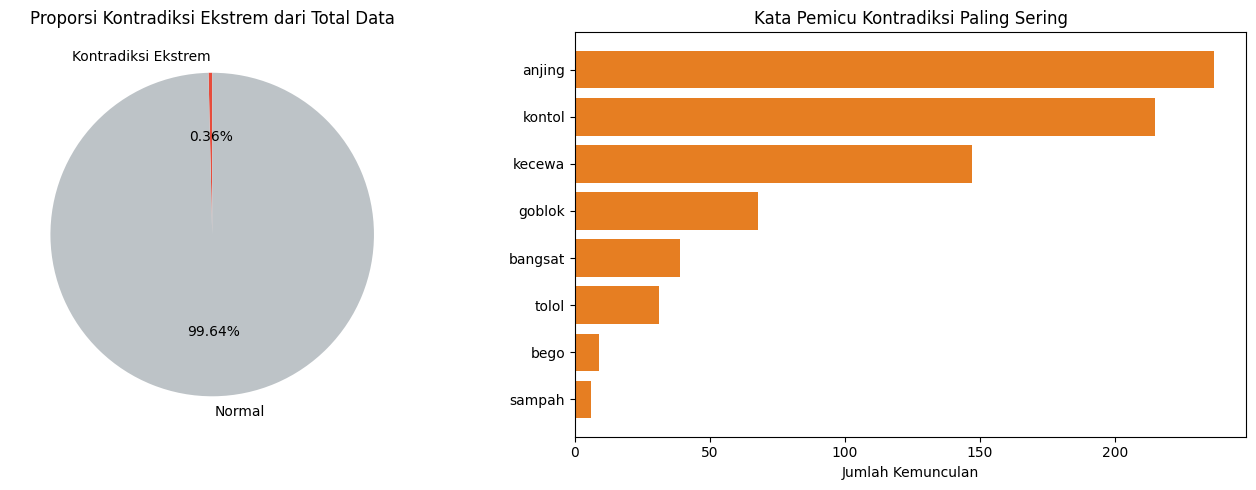


=== SAMPLE 10 KASUS KONTRADIKSI EKSTREM ===


,content,score,sentiment
84051,Kasian tu moonton minta diupdate sudah diupdat...,5,positif
73861,"Kalian semua ngentod,kalian anak FF sama Anak ...",5,positif
165298,masa GM turun ke master 2 🌟 1 gara2 di update ...,5,positif
97124,SEBELAH SINI BANGSAT!!!!!,5,positif
71317,Gem sampahan,5,positif
46756,Game kayak taik habis di update bukan lebih ba...,5,positif
137731,Kadang lengket2 tolong perbaiki biar GK kecewa...,4,positif
23170,"Cakep, cmn masih agak kecewa sma mode cptnya",5,positif
13838,Game nya bagus tapi kenapa setiap masuk ke gam...,4,positif
111512,Mantap anjing,5,positif


In [23]:
# ── BREAKDOWN DISTRIBUSI KONTRADIKSI EKSTREM ──────────────────

strong_negative_words = ['tolol', 'goblok', 'sampah', 'anjing', 'bangsat',
                          'kontol', 'bego', 'kecewa']

def is_extreme_contradiction(row):
    if row['score'] >= 4:
        text = row['content_clean'] if isinstance(row['content_clean'], str) else ''
        if any(w in text for w in strong_negative_words):
            return True
    return False

df_sampled['is_contradiction'] = df_sampled.apply(is_extreme_contradiction, axis=1)

print("=== RINGKASAN UMUM ===")
print(f"Total data: {len(df_sampled):,}")
print(f"Kontradiksi ekstrem terdeteksi: {df_sampled['is_contradiction'].sum():,}")
print(f"Persentase dari total: {df_sampled['is_contradiction'].mean()*100:.2f}%")

# Breakdown per score (4 vs 5)
print("\n=== BREAKDOWN PER SCORE ===")
contradiction_by_score = df_sampled[df_sampled['is_contradiction']]['score'].value_counts().sort_index()
print(contradiction_by_score)

# Breakdown per kata yang paling sering jadi trigger
print("\n=== KATA APA YANG PALING SERING MEMICU KONTRADIKSI ===")
df_contradictions = df_sampled[df_sampled['is_contradiction']].copy()

trigger_counts = {word: 0 for word in strong_negative_words}
for text in df_contradictions['content_clean']:
    if isinstance(text, str):
        for word in strong_negative_words:
            if word in text:
                trigger_counts[word] += 1

trigger_df = pd.DataFrame(
    sorted(trigger_counts.items(), key=lambda x: x[1], reverse=True),
    columns=['kata', 'jumlah_kemunculan']
)
display(trigger_df)

# Distribusi sentiment label asal (semua harusnya 'positif' karena score>=4)
print("\n=== VERIFIKASI: SEMUA KONTRADIKSI INI BERLABEL POSITIF? ===")
print(df_contradictions['sentiment'].value_counts())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: proporsi kontradiksi vs tidak
axes[0].pie(
    [df_sampled['is_contradiction'].sum(), (~df_sampled['is_contradiction']).sum()],
    labels=['Kontradiksi Ekstrem', 'Normal'],
    autopct='%1.2f%%',
    colors=['#e74c3c', '#bdc3c7'],
    startangle=90
)
axes[0].set_title('Proporsi Kontradiksi Ekstrem dari Total Data')

# Chart 2: trigger word
axes[1].barh(trigger_df['kata'], trigger_df['jumlah_kemunculan'], color='#e67e22')
axes[1].invert_yaxis()
axes[1].set_title('Kata Pemicu Kontradiksi Paling Sering')
axes[1].set_xlabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Sample untuk dilihat manual
print("\n=== SAMPLE 10 KASUS KONTRADIKSI EKSTREM ===")
display(
    df_contradictions[['content', 'score', 'sentiment']]
    .sample(min(10, len(df_contradictions)), random_state=42)
)

RINGKASAN SEBELUM vs SETELAH FILTERING
Data SEBELUM filter   : 195,881 rows
Data SETELAH filter   : 195,172 rows
Data yang dibuang     : 709 rows (0.36%)

=== DISTRIBUSI SENTIMEN — SEBELUM FILTER ===
sentiment
positif    97063
negatif    69439
netral     29379
Name: count, dtype: int64
sentiment
positif    49.6
negatif    35.4
netral     15.0
Name: proportion, dtype: float64

=== DISTRIBUSI SENTIMEN — SETELAH FILTER ===
sentiment
positif    96354
negatif    69439
netral     29379
Name: count, dtype: int64
sentiment
positif    49.4
negatif    35.6
netral     15.1
Name: proportion, dtype: float64

=== PREVIEW: 10 ROW YANG DIBUANG (Kontradiksi Ekstrem) ===


,content,score,sentiment
294,Kasian tu moonton minta diupdate sudah diupdat...,5,positif
256,"Kalian semua ngentod,kalian anak FF sama Anak ...",5,positif
613,masa GM turun ke master 2 🌟 1 gara2 di update ...,5,positif
357,SEBELAH SINI BANGSAT!!!!!,5,positif
248,Gem sampahan,5,positif
164,Game kayak taik habis di update bukan lebih ba...,5,positif
499,Kadang lengket2 tolong perbaiki biar GK kecewa...,4,positif
84,"Cakep, cmn masih agak kecewa sma mode cptnya",5,positif
54,Game nya bagus tapi kenapa setiap masuk ke gam...,4,positif
412,Mantap anjing,5,positif



=== PREVIEW: 10 ROW DATA BERSIH (Setelah Filter) ===


,content,score,sentiment
134514,Gamenya bagus sih tapi tiap afk pasti kredit s...,3,netral
51334,Afk ngeselin,3,netral
189844,Rework hero gen1 untuk menyeimbangkan antara hero,4,positif
117995,Nice,5,positif
82440,Game nya bikin bosen akun lama hilang seketika...,1,negatif
153196,Mantap,5,positif
23962,Edan,5,positif
56511,Mantep pokonya the best,3,netral
73760,Saya suka dengan game ini,5,positif
100452,Gudd,5,positif


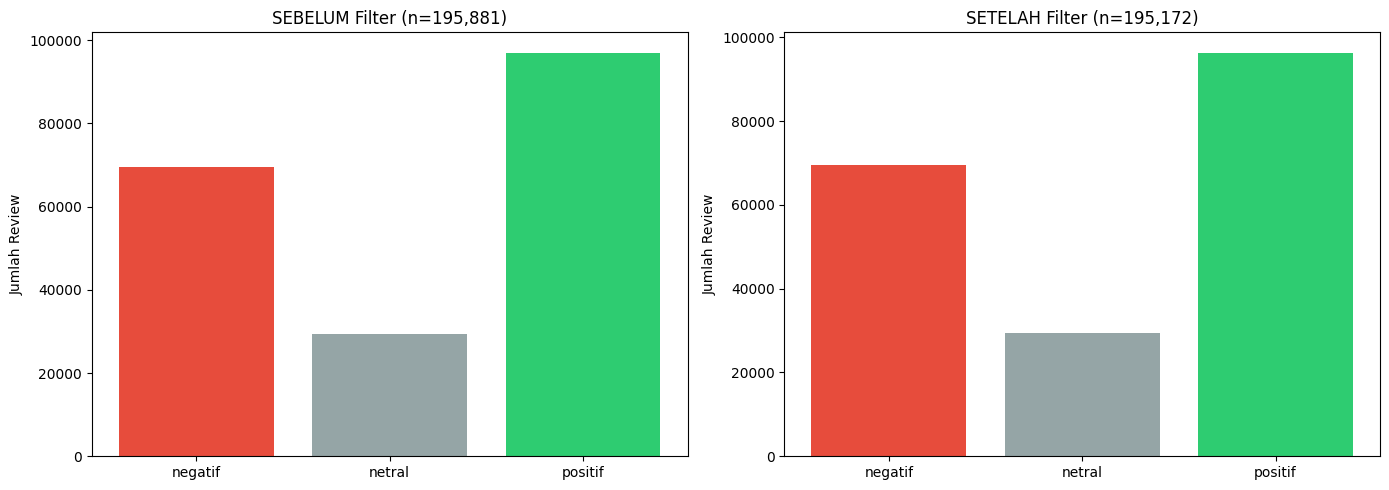


✅ df_clean siap dipakai untuk retrain model (TF-IDF + Logistic Regression)


In [24]:
# ── PREVIEW DATA SETELAH FILTERING KONTRADIKSI EKSTREM ────────

# 1. Pisahkan data bersih vs kontradiksi (asumsi df_sampled sudah punya kolom 'is_contradiction')
df_clean = df_sampled[~df_sampled['is_contradiction']].copy().reset_index(drop=True)
df_contradictions = df_sampled[df_sampled['is_contradiction']].copy().reset_index(drop=True)

# 2. Ringkasan before vs after
print("=" * 60)
print("RINGKASAN SEBELUM vs SETELAH FILTERING")
print("=" * 60)
print(f"Data SEBELUM filter   : {len(df_sampled):,} rows")
print(f"Data SETELAH filter   : {len(df_clean):,} rows")
print(f"Data yang dibuang     : {len(df_contradictions):,} rows ({len(df_contradictions)/len(df_sampled)*100:.2f}%)")

# 3. Distribusi sentimen SEBELUM filter
print("\n=== DISTRIBUSI SENTIMEN — SEBELUM FILTER ===")
print(df_sampled['sentiment'].value_counts())
print(df_sampled['sentiment'].value_counts(normalize=True).round(3) * 100)

# 4. Distribusi sentimen SETELAH filter
print("\n=== DISTRIBUSI SENTIMEN — SETELAH FILTER ===")
print(df_clean['sentiment'].value_counts())
print(df_clean['sentiment'].value_counts(normalize=True).round(3) * 100)

# 5. Preview row yang DIBUANG (supaya bisa lihat data macam apa yang hilang)
print("\n=== PREVIEW: 10 ROW YANG DIBUANG (Kontradiksi Ekstrem) ===")
display(
    df_contradictions[['content', 'score', 'sentiment']]
    .sample(min(10, len(df_contradictions)), random_state=42)
)

# 6. Preview row yang TERSISA (data bersih, untuk perbandingan)
print("\n=== PREVIEW: 10 ROW DATA BERSIH (Setelah Filter) ===")
display(
    df_clean[['content', 'score', 'sentiment']]
    .sample(10, random_state=42)
)

# 7. Visualisasi perbandingan distribusi sentimen before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = df_sampled['sentiment'].value_counts().reindex(['negatif','netral','positif'])
after_counts = df_clean['sentiment'].value_counts().reindex(['negatif','netral','positif'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']

axes[0].bar(before_counts.index, before_counts.values, color=colors)
axes[0].set_title(f'SEBELUM Filter (n={len(df_sampled):,})')
axes[0].set_ylabel('Jumlah Review')

axes[1].bar(after_counts.index, after_counts.values, color=colors)
axes[1].set_title(f'SETELAH Filter (n={len(df_clean):,})')
axes[1].set_ylabel('Jumlah Review')

plt.tight_layout()
plt.show()

print("\n✅ df_clean siap dipakai untuk retrain model (TF-IDF + Logistic Regression)")

interpretasi :
*   Data asli sangat besar (10.3M rows) dan sangat imbalanced — positif (6.2M) jauh mengungguli negatif (2.4M) dan netral (536k).
*   Bahasa 100% Indonesia, penuh slang gaming (gg, lag, dc, noob).
*   Sampling 200k dengan proporsi terjaga adalah keputusan pragmatis, bukan kompromi kualitas.





# EDA & Visualisasi

/tmp/ipykernel_9822/24258146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sampled, x='sentiment', order=['negatif','netral','positif'],


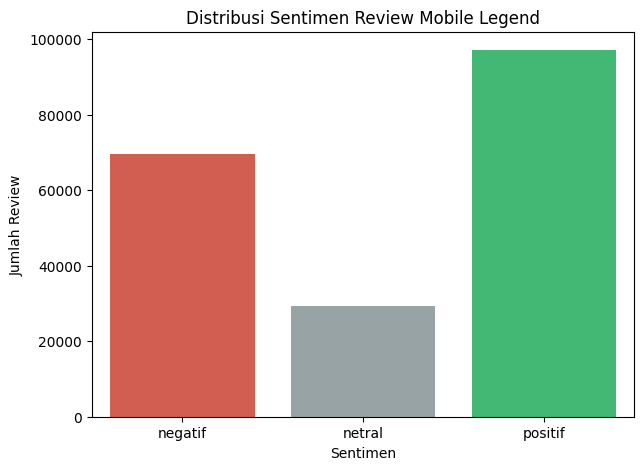

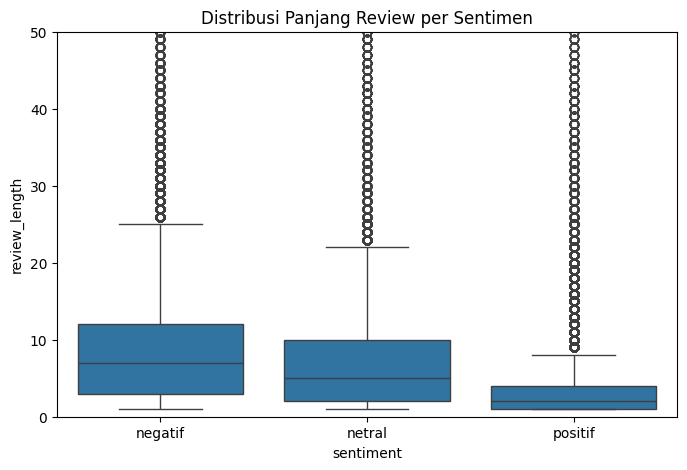

=== STATISTIK PANJANG REVIEW ===
             count      mean       std  min  25%  50%   75%    max
sentiment                                                         
negatif    69439.0  9.347355  8.784552  1.0  3.0  7.0  12.0  132.0
netral     29379.0  7.198237  7.698965  1.0  2.0  5.0  10.0  121.0
positif    97063.0  3.583229  4.609218  1.0  1.0  2.0   4.0  133.0


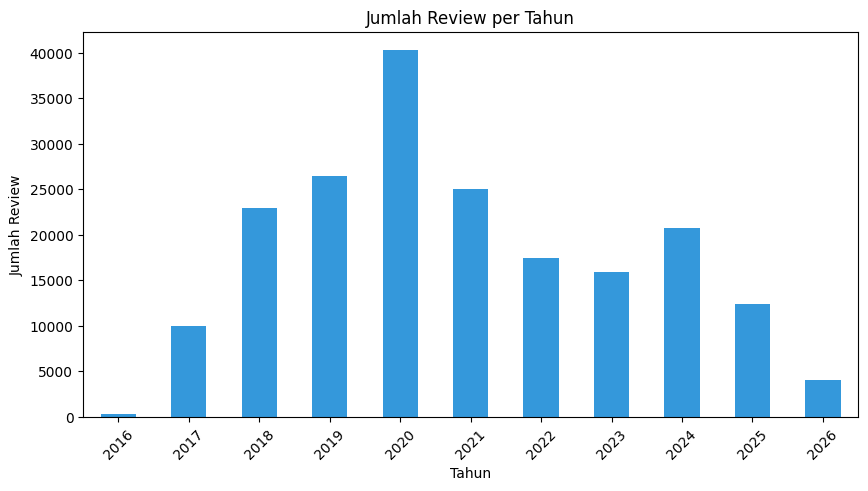

<Figure size 1200x600 with 0 Axes>

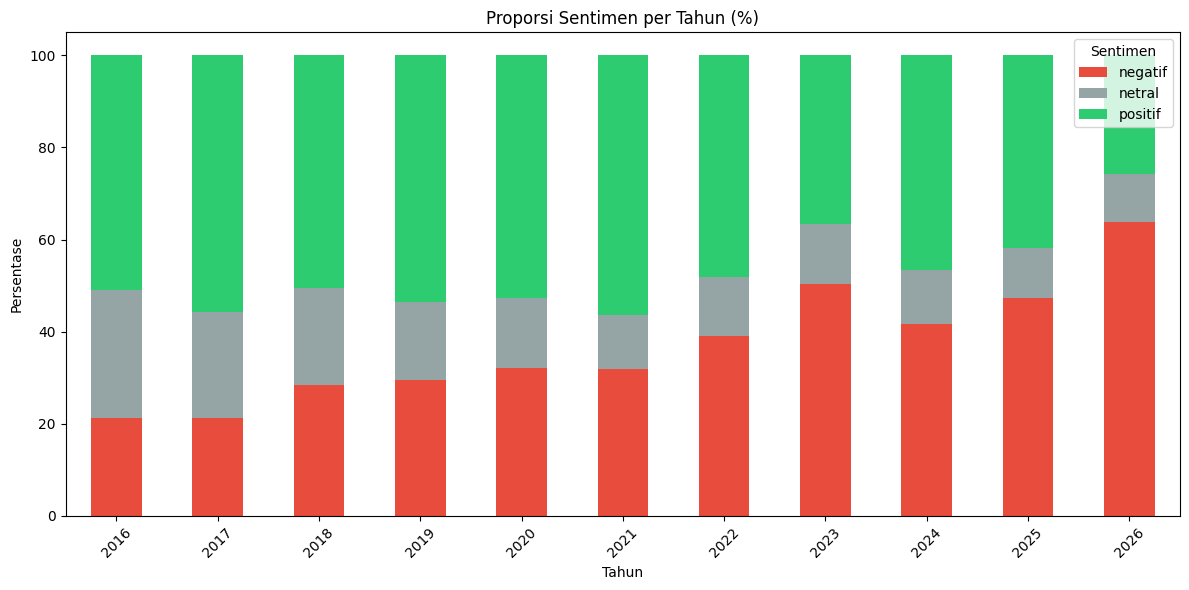

In [25]:
# ── PHASE 3: EDA ──────────────────────────────────────────────

# 1. Distribusi sentimen
plt.figure(figsize=(7,5))
sns.countplot(data=df_sampled, x='sentiment', order=['negatif','netral','positif'],
              palette={'negatif':'#e74c3c','netral':'#95a5a6','positif':'#2ecc71'})
plt.title('Distribusi Sentimen Review Mobile Legend')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

# 2. Panjang review per sentimen
df_sampled['review_length'] = df_sampled['content_clean'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.boxplot(data=df_sampled, x='sentiment', y='review_length',
            order=['negatif','netral','positif'])
plt.title('Distribusi Panjang Review per Sentimen')
plt.ylim(0, 50)
plt.show()

print("=== STATISTIK PANJANG REVIEW ===")
print(df_sampled.groupby('sentiment')['review_length'].describe())

# 3. Trend jumlah review per tahun
plt.figure(figsize=(10,5))
df_sampled.groupby('year').size().plot(kind='bar', color='#3498db')
plt.title('Jumlah Review per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=45)
plt.show()

# 4. Sentimen per tahun (stacked)
sentiment_by_year = df_sampled.groupby(['year','sentiment']).size().unstack(fill_value=0)
sentiment_by_year_pct = sentiment_by_year.div(sentiment_by_year.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
sentiment_by_year_pct[['negatif','netral','positif']].plot(
    kind='bar', stacked=True,
    color=['#e74c3c','#95a5a6','#2ecc71'],
    figsize=(12,6)
)
plt.title('Proporsi Sentimen per Tahun (%)')
plt.xlabel('Tahun')
plt.ylabel('Persentase')
plt.legend(title='Sentimen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

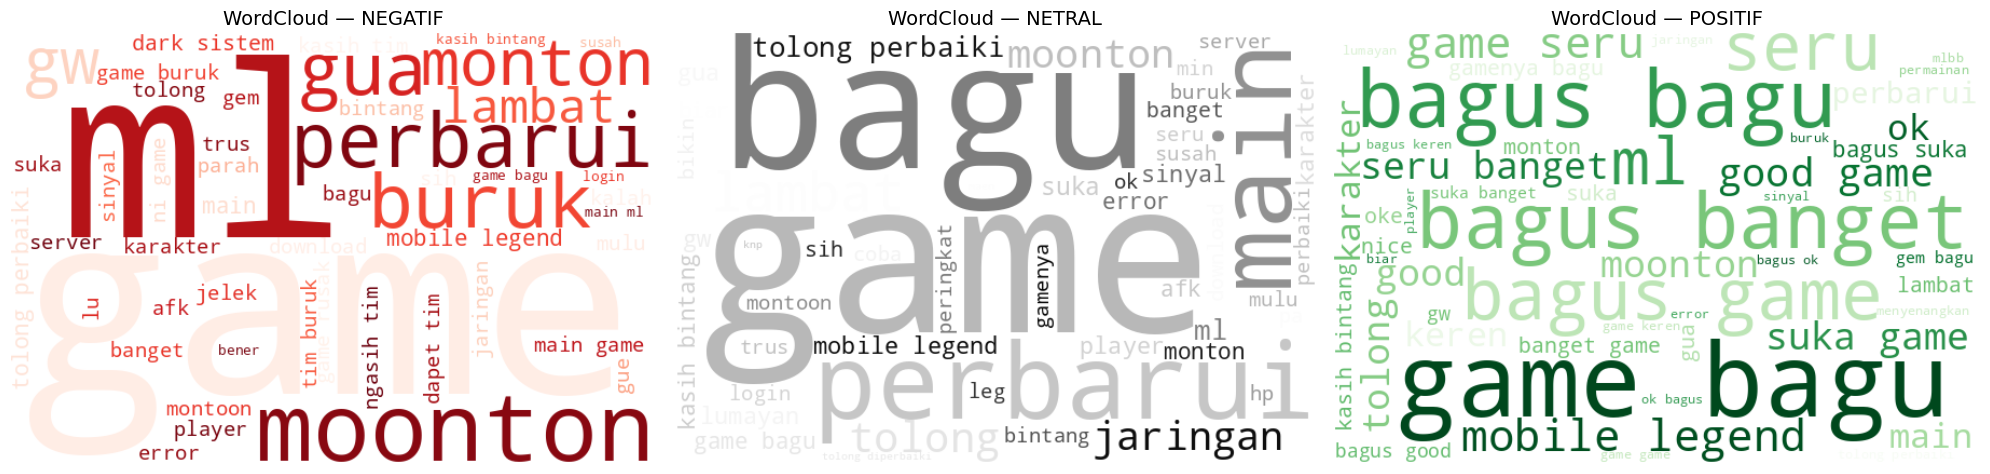

=== TOP 20 KATA — NEGATIF ===
game: 31161
main: 12542
tim: 11029
tolong: 8976
moonton: 8281
lambat: 8028
buruk: 7273
bagus: 6953
perbarui: 6410
ml: 5832
jaringan: 5398
kasih: 5322
gw: 5131
gua: 5118
sinyal: 4806
perbaiki: 4685
mulu: 4479
monton: 4343
sistem: 4292
player: 3946

=== TOP 20 KATA — POSITIF ===
bagus: 29900
game: 22082
seru: 7574
banget: 7034
suka: 6864
good: 4844
tolong: 4339
keren: 4137
main: 4076
ok: 3296
ml: 3101
moonton: 2597
mobile: 2469
kasih: 2451
lambat: 2434
gamenya: 2403
karakter: 2117
gem: 1969
kostum: 1757
permainan: 1643

=== TOP 15 BIGRAM — NEGATIF ===
tolong perbaiki: 1823
dark sistem: 1662
game buruk: 1540
kasih tim: 1371
main game: 1298
game rusak: 1119
ngasih tim: 1061
ni game: 1010
mobile legend: 1004
dapet tim: 990
tim buruk: 961
kasih bintang: 912
main ml: 851
mobile legends: 844
sinyal bagus: 815

=== TOP 15 BIGRAM — POSITIF ===
game bagus: 4852
bagus banget: 2770
game seru: 1840
seru banget: 1391
mobile legends: 1206
good game: 1130
suka game: 1065
g

In [26]:
# ── WORDCLOUD & TOP KEYWORDS ──────────────────────────────────
!pip install wordcloud -q
from wordcloud import WordCloud
from collections import Counter

# 1. WordCloud per sentimen
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, sentiment in enumerate(['negatif', 'netral', 'positif']):
    text = ' '.join(df_sampled[df_sampled['sentiment'] == sentiment]['content_clean'])

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Reds' if sentiment == 'negatif' else ('Greens' if sentiment == 'positif' else 'Greys'),
        max_words=50
    ).generate(text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'WordCloud — {sentiment.upper()}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 2. Top 20 kata per sentimen (lebih presisi dari wordcloud)
def top_words(df, sentiment, n=20):
    text = ' '.join(df[df['sentiment'] == sentiment]['content_clean'])
    words = text.split()
    return Counter(words).most_common(n)

print("=== TOP 20 KATA — NEGATIF ===")
for word, count in top_words(df_sampled, 'negatif'):
    print(f"{word}: {count}")

print("\n=== TOP 20 KATA — POSITIF ===")
for word, count in top_words(df_sampled, 'positif'):
    print(f"{word}: {count}")

# 3. Top bigram per sentimen (lebih informatif untuk konteks)
from sklearn.feature_extraction.text import CountVectorizer

def top_bigrams(df, sentiment, n=15):
    texts = df[df['sentiment'] == sentiment]['content_clean']
    vec = CountVectorizer(ngram_range=(2,2), max_features=1000)
    matrix = vec.fit_transform(texts)
    sums = matrix.sum(axis=0)
    bigram_freq = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)
    return bigram_freq[:n]

print("\n=== TOP 15 BIGRAM — NEGATIF ===")
for bigram, count in top_bigrams(df_sampled, 'negatif'):
    print(f"{bigram}: {count}")

print("\n=== TOP 15 BIGRAM — POSITIF ===")
for bigram, count in top_bigrams(df_sampled, 'positif'):
    print(f"{bigram}: {count}")

# Sentiment Modeling

In [27]:
# ── PHASE 4: MODELING — BINARY CLASSIFICATION ─────────────────

df_binary_v2 = df_clean[df_clean['sentiment'] != 'netral'].copy().reset_index(drop=True)
df_binary_v2['label'] = df_binary_v2['sentiment'].map({'negatif': 0, 'positif': 1})

print("=== DISTRIBUSI BINARY (FINAL — DATA BERSIH) ===")
print(df_binary_v2['sentiment'].value_counts())
print(f"Total: {len(df_binary_v2):,}")

=== DISTRIBUSI BINARY (FINAL — DATA BERSIH) ===
sentiment
positif    96354
negatif    69439
Name: count, dtype: int64
Total: 165,793


=== MODEL FINAL — CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.80      0.87      0.84     13888
     positif       0.90      0.85      0.87     19271

    accuracy                           0.86     33159
   macro avg       0.85      0.86      0.85     33159
weighted avg       0.86      0.86      0.86     33159

F1-Score: 0.8732


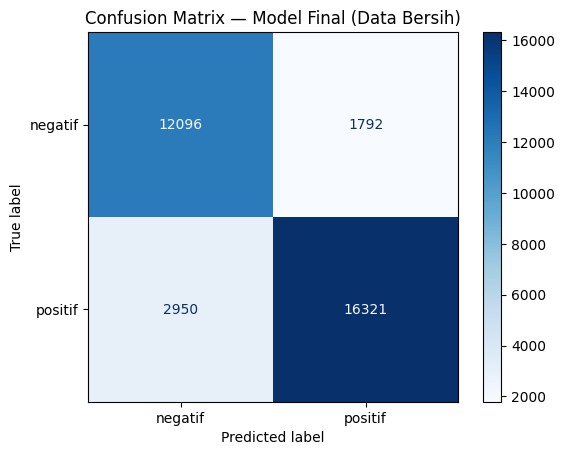

In [28]:
# ── MODEL FINAL: TF-IDF + LOGISTIC REGRESSION (DATA BERSIH) ────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
X_v2 = df_binary_v2['content_clean']
y_v2 = df_binary_v2['label']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

vectorizer_v2 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_tfidf_v2 = vectorizer_v2.fit_transform(X_train_v2)
X_test_tfidf_v2 = vectorizer_v2.transform(X_test_v2)

logreg_v2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg_v2.fit(X_train_tfidf_v2, y_train_v2)

y_pred_v2 = logreg_v2.predict(X_test_tfidf_v2)

print("=== MODEL FINAL — CLASSIFICATION REPORT ===")
print(classification_report(y_test_v2, y_pred_v2, target_names=['negatif','positif']))
print(f"F1-Score: {f1_score(y_test_v2, y_pred_v2):.4f}")

cm_v2 = confusion_matrix(y_test_v2, y_pred_v2)
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['negatif','positif'])
disp_v2.plot(cmap='Blues')
plt.title('Confusion Matrix — Model Final (Data Bersih)')
plt.show()

In [29]:
# ── FEATURE IMPORTANCE — MODEL FINAL ────────────────────────────

feature_names_v2 = vectorizer_v2.get_feature_names_out()
coefs_v2 = logreg_v2.coef_[0]

top_positive_idx_v2 = np.argsort(coefs_v2)[-20:][::-1]
print("=== TOP 20 KATA PENDORONG SENTIMEN POSITIF (FINAL) ===")
for idx in top_positive_idx_v2:
    print(f"{feature_names_v2[idx]}: {coefs_v2[idx]:.3f}")

top_negative_idx_v2 = np.argsort(coefs_v2)[:20]
print("\n=== TOP 20 KATA PENDORONG SENTIMEN NEGATIF (FINAL) ===")
for idx in top_negative_idx_v2:
    print(f"{feature_names_v2[idx]}: {coefs_v2[idx]:.3f}")

=== TOP 20 KATA PENDORONG SENTIMEN POSITIF (FINAL) ===
not bad: 4.231
terbaik: 3.696
menyukai: 3.566
good: 3.486
love: 3.471
menghibur: 3.294
suka banget: 3.274
keren: 3.137
nice: 3.020
seruu: 2.902
mantab: 2.895
best: 2.873
like: 2.847
good game: 2.784
semangat: 2.697
seruuu: 2.680
suka game: 2.674
wow: 2.662
mantep: 2.620
ketagihan: 2.609

=== TOP 20 KATA PENDORONG SENTIMEN NEGATIF (FINAL) ===
anjing: -9.051
kecewa: -8.805
kontol: -7.075
goblok: -5.659
rusak: -5.079
bangsat: -4.746
tim: -4.532
parah: -4.171
mending: -3.953
plagiat: -3.950
babi: -3.892
uninstal: -3.852
gajelas: -3.746
buruk: -3.519
bangkrut: -3.408
seimbang: -3.396
matchmaking: -3.377
adil: -3.336
aneh: -3.296
tai: -3.248


=== XGBOOST v2 (DATA BERSIH) — CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.82      0.75      0.78     13888
     positif       0.83      0.89      0.86     19271

    accuracy                           0.83     33159
   macro avg       0.83      0.82      0.82     33159
weighted avg       0.83      0.83      0.83     33159

F1-Score: 0.8566


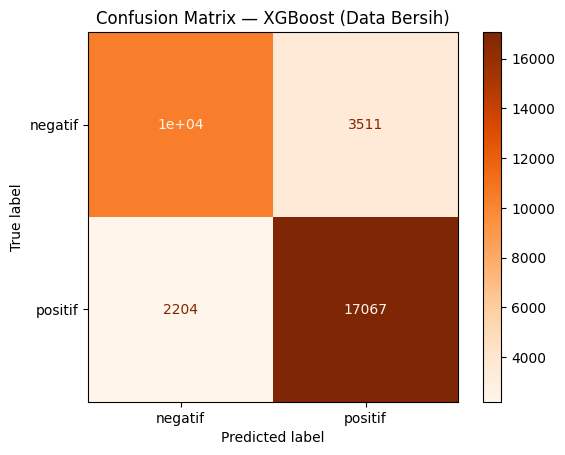

In [30]:
# ── XGBOOST DENGAN DATA BERSIH (v2) ─────────────────────────────

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_v2.fit(X_train_tfidf_v2, y_train_v2)
y_pred_xgb_v2 = xgb_v2.predict(X_test_tfidf_v2)

print("=== XGBOOST v2 (DATA BERSIH) — CLASSIFICATION REPORT ===")
print(classification_report(y_test_v2, y_pred_xgb_v2, target_names=['negatif','positif']))
print(f"F1-Score: {f1_score(y_test_v2, y_pred_xgb_v2):.4f}")

cm_xgb_v2 = confusion_matrix(y_test_v2, y_pred_xgb_v2)
disp_xgb_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_v2, display_labels=['negatif','positif'])
disp_xgb_v2.plot(cmap='Oranges')
plt.title('Confusion Matrix — XGBoost (Data Bersih)')
plt.show()

In [32]:
# ── COMPARISON TABLE — HANYA VERSI FINAL (TIDAK BUTUH VARIABEL LAMA) ──

comparison_final = pd.DataFrame({
    'Model': [
        'Logistic Regression (final)',
        'XGBoost (final)'
    ],
    'Accuracy': [
        (y_pred_v2 == y_test_v2).mean(),
        (y_pred_xgb_v2 == y_test_v2).mean()
    ],
    'F1-Score': [
        f1_score(y_test_v2, y_pred_v2),
        f1_score(y_test_v2, y_pred_xgb_v2)
    ]
})

print("=== MODEL COMPARISON — FINAL ===")
display(comparison_final)

=== MODEL COMPARISON — FINAL ===


,Model,Accuracy,F1-Score
0,Logistic Regression (final),0.856992,0.873154
1,XGBoost (final),0.827649,0.856584


In [33]:
# ── FEATURE IMPORTANCE — MODEL FINAL (DATA BERSIH) ──────────────

feature_names_v2 = vectorizer_v2.get_feature_names_out()
coefs_v2 = logreg_v2.coef_[0]

# Top kata pendorong sentimen POSITIF
top_positive_idx_v2 = np.argsort(coefs_v2)[-20:][::-1]
print("=== TOP 20 KATA PENDORONG SENTIMEN POSITIF (FINAL) ===")
for idx in top_positive_idx_v2:
    print(f"{feature_names_v2[idx]}: {coefs_v2[idx]:.3f}")

# Top kata pendorong sentimen NEGATIF
top_negative_idx_v2 = np.argsort(coefs_v2)[:20]
print("\n=== TOP 20 KATA PENDORONG SENTIMEN NEGATIF (FINAL) ===")
for idx in top_negative_idx_v2:
    print(f"{feature_names_v2[idx]}: {coefs_v2[idx]:.3f}")

=== TOP 20 KATA PENDORONG SENTIMEN POSITIF (FINAL) ===
not bad: 4.231
terbaik: 3.696
menyukai: 3.566
good: 3.486
love: 3.471
menghibur: 3.294
suka banget: 3.274
keren: 3.137
nice: 3.020
seruu: 2.902
mantab: 2.895
best: 2.873
like: 2.847
good game: 2.784
semangat: 2.697
seruuu: 2.680
suka game: 2.674
wow: 2.662
mantep: 2.620
ketagihan: 2.609

=== TOP 20 KATA PENDORONG SENTIMEN NEGATIF (FINAL) ===
anjing: -9.051
kecewa: -8.805
kontol: -7.075
goblok: -5.659
rusak: -5.079
bangsat: -4.746
tim: -4.532
parah: -4.171
mending: -3.953
plagiat: -3.950
babi: -3.892
uninstal: -3.852
gajelas: -3.746
buruk: -3.519
bangkrut: -3.408
seimbang: -3.396
matchmaking: -3.377
adil: -3.336
aneh: -3.296
tai: -3.248


In [34]:
# ── DISPLAY LAYER: Profanity Censoring (HANYA untuk presentasi) ──
import re

profanity_list = [
    'anjing', 'anjir', 'babi', 'taik', 'tai', 'goblok',
    'kontol', 'bangsat', 'bego', 'tolol', 'sialan',
    'memek', 'jancok', 'bajingan', 'asu', 'kampret'
]

def censor_for_display(text):
    """
    PENTING: Fungsi ini HANYA dipakai untuk kolom display/presentasi
    (dashboard, README, sample review di notebook).
    TIDAK DIPAKAI untuk data yang masuk ke model atau analisis.
    """
    if not isinstance(text, str):
        return text

    result = text
    for word in profanity_list:
        pattern = re.compile(r'\b' + re.escape(word) + r'\b', re.IGNORECASE)
        if len(word) > 2:
            censored = word[0] + '*' * (len(word) - 2) + word[-1]
        else:
            censored = '*' * len(word)
        result = pattern.sub(censored, result)

    return result

# Buat kolom display untuk df_clean (data final yang sudah difilter kontradiksi)
df_clean['content_display'] = df_clean['content'].apply(censor_for_display)

# Sinkronkan juga ke df_binary_v2 (subset binary dari df_clean)
df_binary_v2['content_display'] = df_binary_v2['content'].apply(censor_for_display)

# Verifikasi: tunjukkan before-after pada review yang mengandung kata kasar
print("=== VERIFIKASI CENSORING (DATA FINAL) ===\n")
sample_check_v2 = df_clean[
    df_clean['content'].str.lower().str.contains('|'.join(profanity_list), na=False)
][['content', 'content_display']].head(5)

for idx, row in sample_check_v2.iterrows():
    print(f"ASLI    : {row['content']}")
    print(f"DISPLAY : {row['content_display']}")
    print("-" * 80)

print(f"\n✅ Total review dengan profanity (data final): {df_clean['content'].str.lower().str.contains('|'.join(profanity_list), na=False).sum():,}")
print(f"✅ content_clean (untuk model) tetap utuh, tidak tersentuh proses sensor")

=== VERIFIKASI CENSORING (DATA FINAL) ===

ASLI    : Game taek jaringan 4g lag asu .
DISPLAY : Game taek jaringan 4g lag a*u .
--------------------------------------------------------------------------------
ASLI    : Game anjing kontol ping turun mulu anjing kontol
DISPLAY : Game a****g k****l ping turun mulu a****g k****l
--------------------------------------------------------------------------------
ASLI    : Saya dari dulu main game ini tapi setelah update saya tidak bisa masuk ke game nya apa karena mobile legend tidak support hp ke ntang ?
DISPLAY : Saya dari dulu main game ini tapi setelah update saya tidak bisa masuk ke game nya apa karena mobile legend tidak support hp ke ntang ?
--------------------------------------------------------------------------------
ASLI    : Susah sekali naik pangkat nya aku udh masuk elite kok bintang nya turun 2 lgi ngabisin kouta aja
DISPLAY : Susah sekali naik pangkat nya aku udh masuk elite kok bintang nya turun 2 lgi ngabisin kouta aja
------

# Aspect Based Sentiment

In [36]:
# ── DEFINISI ULANG: ASPECT KEYWORDS & EXTRACT FUNCTION ──────────

aspect_keywords = {
    'Matchmaking & Fairness': [
        'tim', 'matchmaking', 'adil', 'seimbang', 'kasih tim',
        'dark sistem', 'ngasih tim', 'dapet tim'
    ],
    'Bug & Performa Teknis': [
        'rusak', 'error', 'sistem', 'lambat', 'sinyal', 'jaringan',
        'server', 'lag', 'afk', 'ngelag', 'disconnect', 'dc'
    ],
    'Konten & Originalitas': [
        'plagiat', 'karakter', 'hero', 'kostum', 'skin', 'event'
    ],
    'Kepuasan/Frustrasi Umum': [
        'kecewa', 'mending', 'uninstal', 'bangkrut', 'parah', 'jelek'
    ],
    'Apresiasi Positif': [
        'bagus', 'seru', 'keren', 'menghibur', 'mantap', 'suka',
        'nice', 'good', 'terbaik', 'semangat'
    ]
}

def extract_aspects(text):
    """Deteksi aspek mana yang muncul dalam satu review (bisa lebih dari 1)"""
    if not isinstance(text, str):
        return []

    found_aspects = []
    text_lower = text.lower()

    for aspect, keywords in aspect_keywords.items():
        if any(kw in text_lower for kw in keywords):
            found_aspects.append(aspect)

    return found_aspects if found_aspects else ['Tidak Terklasifikasi']

print("✅ extract_aspects dan aspect_keywords berhasil didefinisikan ulang")

✅ extract_aspects dan aspect_keywords berhasil didefinisikan ulang


In [37]:
# ── CEK SEMUA DEPENDENCY PENTING ─────────────────────────────────

checks = {
    'Library': ['pd', 'np', 'plt', 'sns'],
    'Sklearn': ['train_test_split', 'TfidfVectorizer', 'LogisticRegression',
                'f1_score', 'classification_report', 'confusion_matrix'],
    'XGBoost': ['XGBClassifier'],
    'Data': ['df_sampled', 'df_clean', 'df_binary_v2'],
    'Model': ['vectorizer_v2', 'logreg_v2', 'xgb_v2'],
    'Fungsi Custom': ['preprocess', 'extract_aspects', 'censor_for_display'],
    'Kamus': ['slang_dict', 'aspect_keywords', 'profanity_list']
}

for category, vars_list in checks.items():
    print(f"\n=== {category} ===")
    for var in vars_list:
        status = '✅' if var in dir() else '❌ HILANG'
        print(f"  {var}: {status}")


=== Library ===
  pd: ✅
  np: ✅
  plt: ✅
  sns: ✅

=== Sklearn ===
  train_test_split: ✅
  TfidfVectorizer: ✅
  LogisticRegression: ✅
  f1_score: ✅
  classification_report: ✅
  confusion_matrix: ✅

=== XGBoost ===
  XGBClassifier: ✅

=== Data ===
  df_sampled: ✅
  df_clean: ✅
  df_binary_v2: ✅

=== Model ===
  vectorizer_v2: ✅
  logreg_v2: ✅
  xgb_v2: ✅

=== Fungsi Custom ===
  preprocess: ✅
  extract_aspects: ✅
  censor_for_display: ✅

=== Kamus ===
  slang_dict: ✅
  aspect_keywords: ✅
  profanity_list: ✅


In [38]:
# ── CEK VARIABEL HASIL PREDIKSI & SPLIT ──────────────────────────

checks_extra = {
    'Split & Prediksi (versi lama)': ['X_train', 'X_test', 'y_train', 'y_test',
                                        'y_pred_logreg', 'y_pred_xgb'],
    'Split & Prediksi (versi bersih/_v2)': ['X_train_v2', 'X_test_v2', 'y_train_v2', 'y_test_v2',
                                              'y_pred_v2', 'y_pred_xgb_v2'],
    'TF-IDF Matrix': ['X_train_tfidf', 'X_test_tfidf', 'X_train_tfidf_v2', 'X_test_tfidf_v2'],
    'ABSA & Timeline': ['df_aspects', 'df_aspects_v2', 'aspect_sentiment_pct', 'aspect_sentiment_pct_v2']
}

for category, vars_list in checks_extra.items():
    print(f"\n=== {category} ===")
    for var in vars_list:
        status = '✅' if var in dir() else '❌ HILANG'
        print(f"  {var}: {status}")


=== Split & Prediksi (versi lama) ===
  X_train: ❌ HILANG
  X_test: ❌ HILANG
  y_train: ❌ HILANG
  y_test: ❌ HILANG
  y_pred_logreg: ❌ HILANG
  y_pred_xgb: ❌ HILANG

=== Split & Prediksi (versi bersih/_v2) ===
  X_train_v2: ✅
  X_test_v2: ✅
  y_train_v2: ✅
  y_test_v2: ✅
  y_pred_v2: ✅
  y_pred_xgb_v2: ✅

=== TF-IDF Matrix ===
  X_train_tfidf: ❌ HILANG
  X_test_tfidf: ❌ HILANG
  X_train_tfidf_v2: ✅
  X_test_tfidf_v2: ✅

=== ABSA & Timeline ===
  df_aspects: ❌ HILANG
  df_aspects_v2: ❌ HILANG
  aspect_sentiment_pct: ❌ HILANG
  aspect_sentiment_pct_v2: ❌ HILANG


=== JUMLAH REVIEW PER ASPEK (FINAL) ===
aspects
Apresiasi Positif          65221
Bug & Performa Teknis      29743
Matchmaking & Fairness     14207
Kepuasan/Frustrasi Umum    10501
Konten & Originalitas       8183
Name: count, dtype: int64

=== ASPEK × SENTIMEN — % (FINAL) ===


sentiment,negatif,positif
aspects,,
Apresiasi Positif,15.9,84.1
Bug & Performa Teknis,78.3,21.7
Kepuasan/Frustrasi Umum,87.5,12.5
Konten & Originalitas,54.1,45.9
Matchmaking & Fairness,86.2,13.8


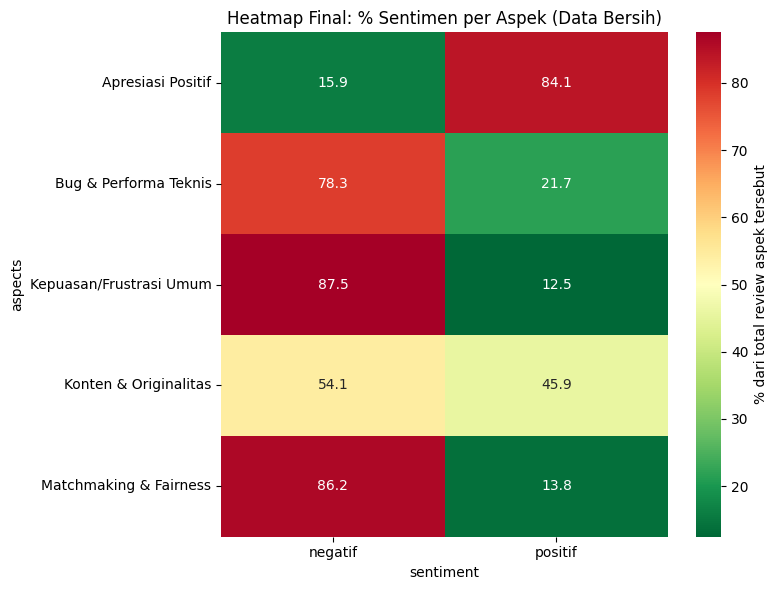

In [39]:
# ── ABSA — DATA FINAL ───────────────────────────────────────────

df_binary_v2['aspects'] = df_binary_v2['content_clean'].apply(extract_aspects)
df_binary_v2['version_major'] = df_binary_v2['reviewCreatedVersion'].str.extract(r'^(\d+\.\d+)')

df_aspects_v2 = df_binary_v2.explode('aspects')
df_aspects_v2 = df_aspects_v2[df_aspects_v2['aspects'] != 'Tidak Terklasifikasi']

print("=== JUMLAH REVIEW PER ASPEK (FINAL) ===")
aspect_counts_v2 = df_aspects_v2['aspects'].value_counts()
print(aspect_counts_v2)

aspect_sentiment_v2 = pd.crosstab(df_aspects_v2['aspects'], df_aspects_v2['sentiment'])
aspect_sentiment_pct_v2 = aspect_sentiment_v2.div(aspect_sentiment_v2.sum(axis=1), axis=0) * 100

print("\n=== ASPEK × SENTIMEN — % (FINAL) ===")
display(aspect_sentiment_pct_v2.round(1))

plt.figure(figsize=(8,6))
sns.heatmap(
    aspect_sentiment_pct_v2[['negatif','positif']],
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    cbar_kws={'label': '% dari total review aspek tersebut'}
)
plt.title('Heatmap Final: % Sentimen per Aspek (Data Bersih)')
plt.tight_layout()
plt.show()

=== JUMLAH REVIEW PER ASPEK (FINAL) ===
aspects
Apresiasi Positif          65221
Bug & Performa Teknis      29743
Matchmaking & Fairness     14207
Kepuasan/Frustrasi Umum    10501
Konten & Originalitas       8183
Name: count, dtype: int64


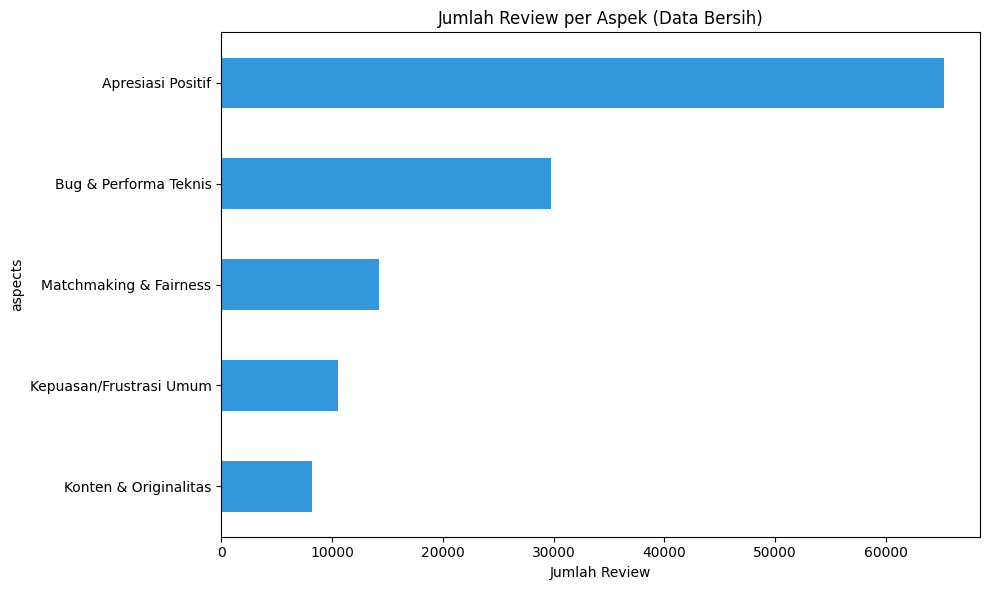

In [40]:
# Explode supaya 1 review dengan multiple aspek jadi multiple rows
df_aspects_v2 = df_binary_v2.explode('aspects')
df_aspects_v2 = df_aspects_v2[df_aspects_v2['aspects'] != 'Tidak Terklasifikasi']

print("=== JUMLAH REVIEW PER ASPEK (FINAL) ===")
aspect_counts_v2 = df_aspects_v2['aspects'].value_counts()
print(aspect_counts_v2)

plt.figure(figsize=(10,6))
aspect_counts_v2.plot(kind='barh', color='#3498db')
plt.title('Jumlah Review per Aspek (Data Bersih)')
plt.xlabel('Jumlah Review')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== JUMLAH ABSOLUT: ASPEK × SENTIMEN (FINAL) ===


sentiment,negatif,positif
aspects,,
Apresiasi Positif,10394,54827
Bug & Performa Teknis,23295,6448
Kepuasan/Frustrasi Umum,9190,1311
Konten & Originalitas,4430,3753
Matchmaking & Fairness,12243,1964



=== PERSENTASE: ASPEK × SENTIMEN (FINAL) ===


sentiment,negatif,positif
aspects,,
Apresiasi Positif,15.9,84.1
Bug & Performa Teknis,78.3,21.7
Kepuasan/Frustrasi Umum,87.5,12.5
Konten & Originalitas,54.1,45.9
Matchmaking & Fairness,86.2,13.8


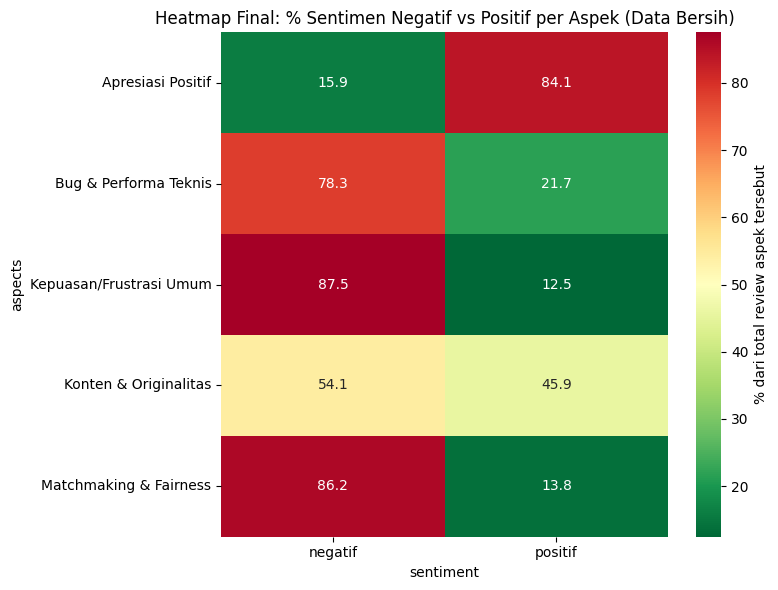

In [41]:
# Cross-tab aspek vs sentimen
aspect_sentiment_v2 = pd.crosstab(df_aspects_v2['aspects'], df_aspects_v2['sentiment'])
aspect_sentiment_pct_v2 = aspect_sentiment_v2.div(aspect_sentiment_v2.sum(axis=1), axis=0) * 100

print("=== JUMLAH ABSOLUT: ASPEK × SENTIMEN (FINAL) ===")
display(aspect_sentiment_v2)

print("\n=== PERSENTASE: ASPEK × SENTIMEN (FINAL) ===")
display(aspect_sentiment_pct_v2.round(1))

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    aspect_sentiment_pct_v2[['negatif','positif']],
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    cbar_kws={'label': '% dari total review aspek tersebut'}
)
plt.title('Heatmap Final: % Sentimen Negatif vs Positif per Aspek (Data Bersih)')
plt.tight_layout()
plt.show()

# Patch Timeline Analysis

=== TOP 15 VERSI DENGAN % NEGATIF TERTINGGI (FINAL, min 100 review) ===
2.1.40.11461: 80.2% negatif (n=126)
2.1.31.11233: 77.6% negatif (n=550)
2.1.18.11201: 74.5% negatif (n=729)
2.1.47.11491: 73.4% negatif (n=644)
1.9.29.10113: 68.6% negatif (n=395)
2.1.41.11465: 67.7% negatif (n=536)
2.1.67.11733: 67.1% negatif (n=414)
2.1.61.11705: 66.2% negatif (n=662)
1.7.59.8262: 65.6% negatif (n=660)
19.2.21.104: 65.1% negatif (n=284)
1.8.80.9553: 64.8% negatif (n=355)
1.7.82.8551: 64.3% negatif (n=589)
1.8.20.8941: 63.2% negatif (n=478)
1.7.94.8681: 62.4% negatif (n=942)
1.9.68.10631: 62.0% negatif (n=300)

=== % NEGATIF PER MAJOR VERSION (FINAL, kronologis, min 300 review) ===


,pct_negatif,jumlah_review,tanggal_rata
version_major,,,
1.1,32.574680,703,2017-09-04 07:35:28.729729792
1.2,35.551213,11257,2018-05-23 12:01:33.987918592
1.3,40.450782,10870,2019-05-22 05:56:02.171849216
1.4,34.084785,22268,2020-05-03 20:48:32.457472768
1.5,36.470733,16298,2021-03-12 19:25:01.039023104
1.6,41.536050,10208,2022-04-13 21:16:24.510579968
1.7,57.427777,8273,2023-04-05 23:18:42.845521408
1.8,46.697892,10675,2024-03-25 11:36:33.165995264
19.2,40.918580,1437,2024-10-21 18:07:31.123869440


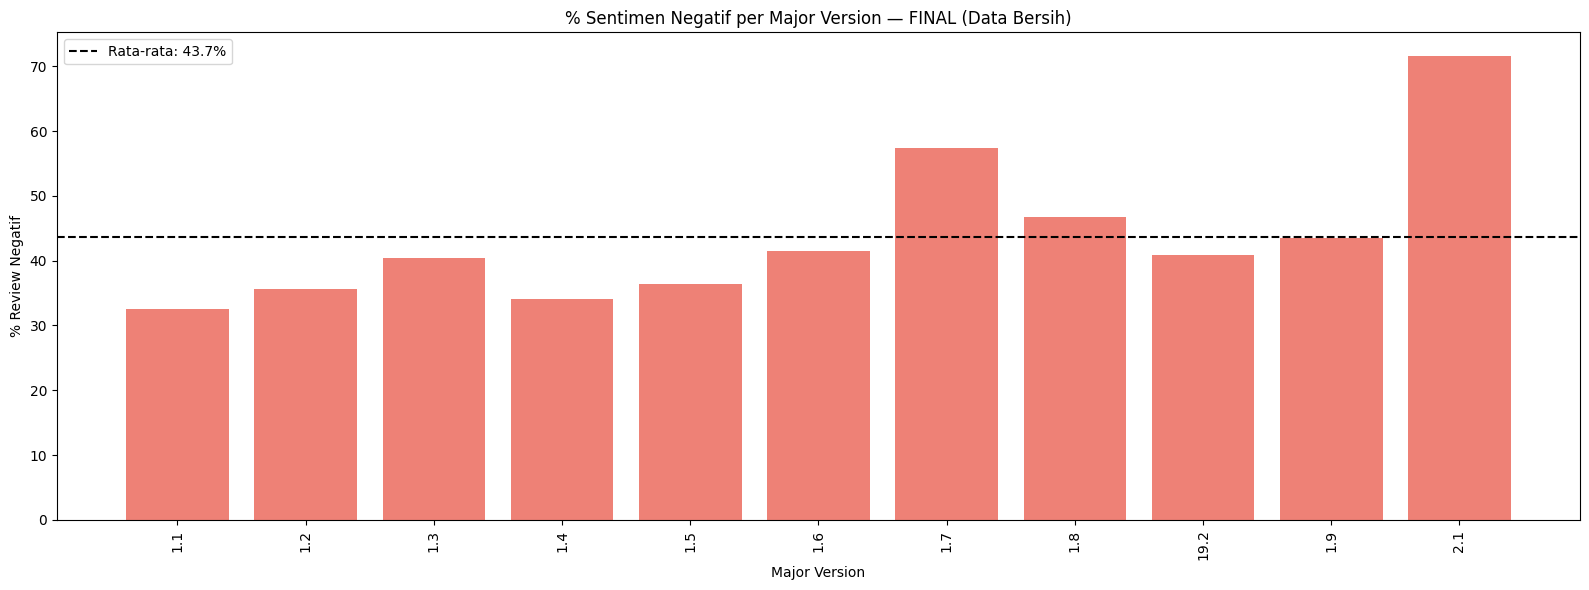

In [42]:
# ── PATCH TIMELINE — DATA FINAL ─────────────────────────────────

version_counts_v2 = df_binary_v2['reviewCreatedVersion'].value_counts()
valid_versions_v2 = version_counts_v2[version_counts_v2 >= 100].index

df_timeline_v2 = df_binary_v2[df_binary_v2['reviewCreatedVersion'].isin(valid_versions_v2)].copy()

version_sentiment_v2 = df_timeline_v2.groupby('reviewCreatedVersion')['sentiment'].apply(
    lambda x: (x == 'negatif').mean() * 100
).sort_index()

print("=== TOP 15 VERSI DENGAN % NEGATIF TERTINGGI (FINAL, min 100 review) ===")
top_negative_versions_v2 = version_sentiment_v2.sort_values(ascending=False).head(15)
for version, pct in top_negative_versions_v2.items():
    count = version_counts_v2[version]
    print(f"{version}: {pct:.1f}% negatif (n={count})")

df_timeline_v2['version_major'] = df_timeline_v2['reviewCreatedVersion'].str.extract(r'^(\d+\.\d+)')

major_version_sentiment_v2 = df_timeline_v2.groupby('version_major').agg(
    pct_negatif=('sentiment', lambda x: (x == 'negatif').mean() * 100),
    jumlah_review=('sentiment', 'count'),
    tanggal_rata=('at', 'mean')
).sort_values('tanggal_rata')

major_version_sentiment_filtered_v2 = major_version_sentiment_v2[
    major_version_sentiment_v2['jumlah_review'] >= 300
]

print("\n=== % NEGATIF PER MAJOR VERSION (FINAL, kronologis, min 300 review) ===")
display(major_version_sentiment_filtered_v2)

plt.figure(figsize=(16,6))
x = range(len(major_version_sentiment_filtered_v2))
plt.bar(x, major_version_sentiment_filtered_v2['pct_negatif'], color='#e74c3c', alpha=0.7)
plt.xticks(x, major_version_sentiment_filtered_v2.index, rotation=90)
plt.axhline(y=major_version_sentiment_filtered_v2['pct_negatif'].mean(),
            color='black', linestyle='--',
            label=f'Rata-rata: {major_version_sentiment_filtered_v2["pct_negatif"].mean():.1f}%')
plt.title('% Sentimen Negatif per Major Version — FINAL (Data Bersih)')
plt.ylabel('% Review Negatif')
plt.xlabel('Major Version')
plt.legend()
plt.tight_layout()
plt.show()

=== DELTA FINAL (v2.1 - v1.9) — DATA BERSIH ===


version_major,1.9,2.1,delta
aspects,,,
Bug & Performa Teknis,22.883979,31.234129,8.350150
Matchmaking & Fairness,19.073540,26.256983,7.183443
Kepuasan/Frustrasi Umum,6.713630,9.827324,3.113693
Konten & Originalitas,6.628242,5.129507,-1.498735
Apresiasi Positif,44.700608,27.552057,-17.148552


<Figure size 1000x600 with 0 Axes>

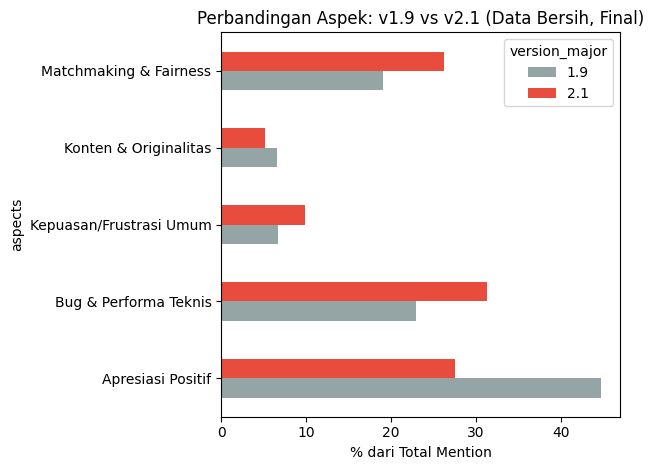

In [43]:
# ── CROSS-REFERENCE FINAL: v1.9 vs v2.1 ─────────────────────────

df_aspects_v2['version_major'] = df_aspects_v2['reviewCreatedVersion'].str.extract(r'^(\d+\.\d+)')

comparison_versions_v2 = df_aspects_v2[df_aspects_v2['version_major'].isin(['1.9', '2.1'])]

aspect_by_version_v2 = pd.crosstab(
    comparison_versions_v2['aspects'],
    comparison_versions_v2['version_major'],
    normalize='columns'
) * 100

aspect_by_version_v2['delta'] = aspect_by_version_v2['2.1'] - aspect_by_version_v2['1.9']

print("=== DELTA FINAL (v2.1 - v1.9) — DATA BERSIH ===")
display(aspect_by_version_v2[['1.9','2.1','delta']].sort_values('delta', ascending=False))

plt.figure(figsize=(10,6))
aspect_by_version_v2[['1.9','2.1']].plot(kind='barh', color=['#95a5a6','#e74c3c'])
plt.title('Perbandingan Aspek: v1.9 vs v2.1 (Data Bersih, Final)')
plt.xlabel('% dari Total Mention')
plt.tight_layout()
plt.show()

# Dashboard

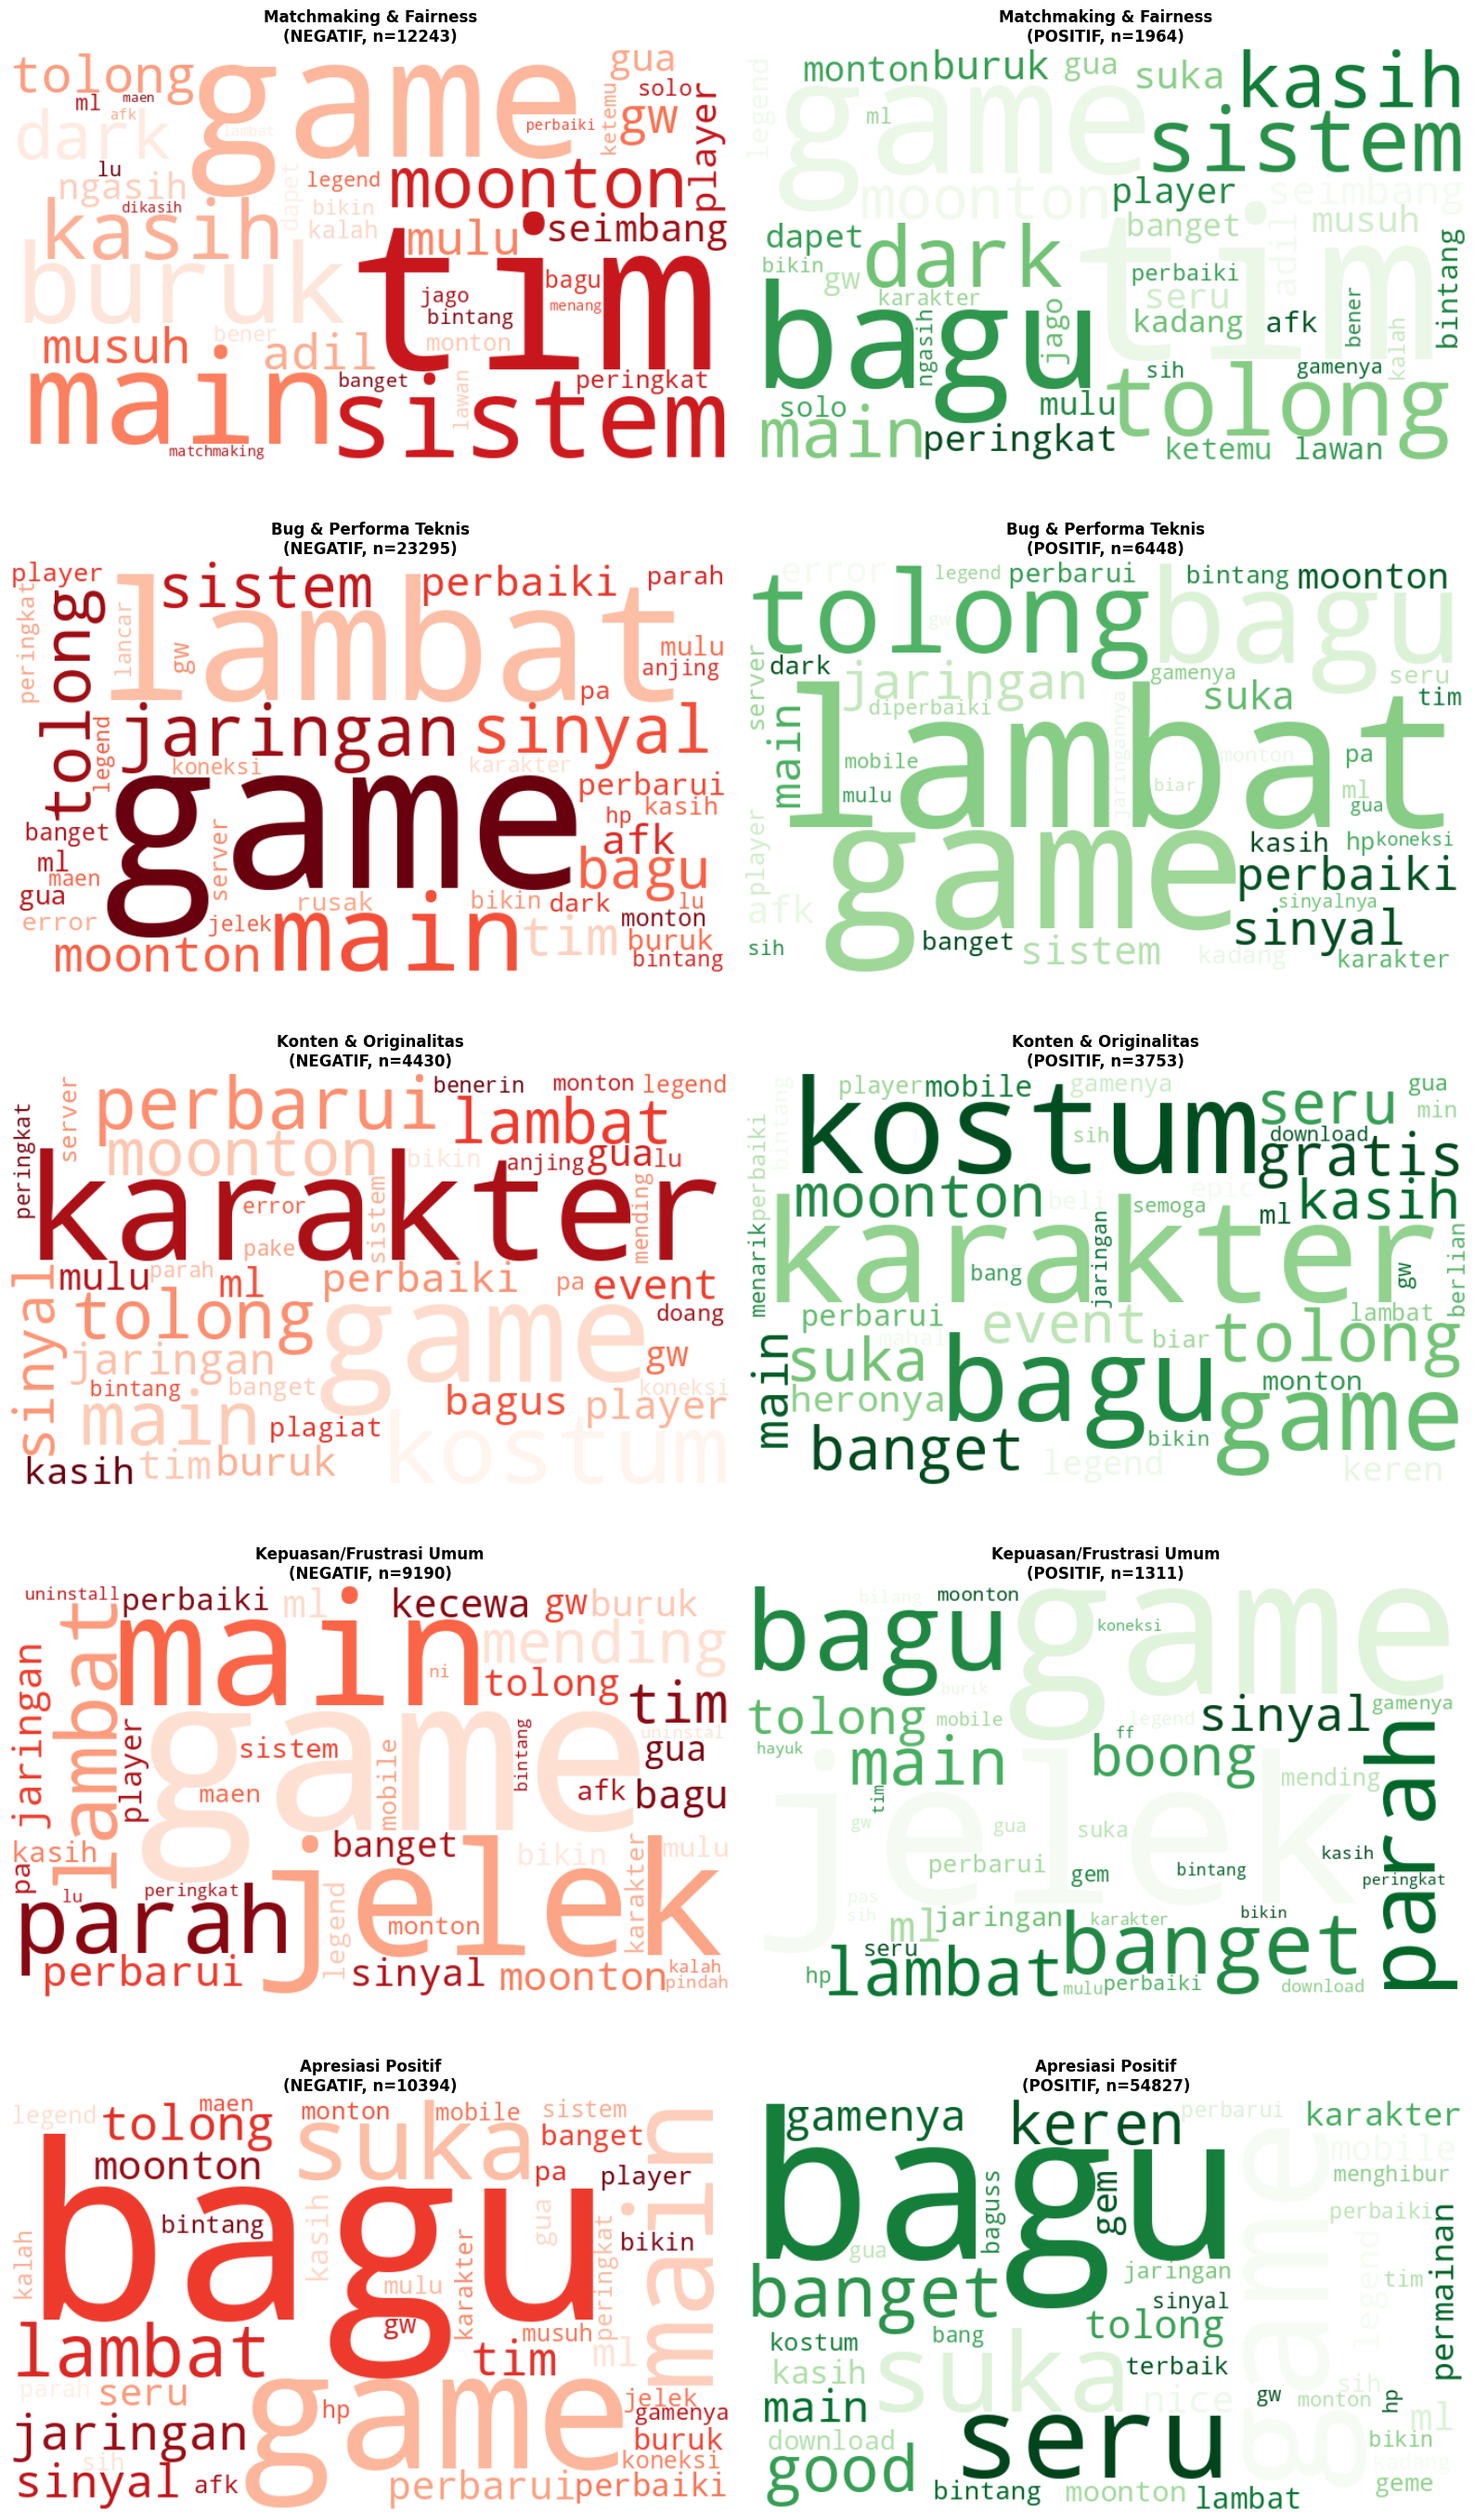

✅ WordCloud final selesai dibuat dan disimpan sebagai 'wordcloud_aspek_final.png'


In [44]:
# ── WORDCLOUD PER ASPEK × SENTIMEN (DATA FINAL) ───────────────
!pip install wordcloud -q
from wordcloud import WordCloud

aspects_list = [
    'Matchmaking & Fairness',
    'Bug & Performa Teknis',
    'Konten & Originalitas',
    'Kepuasan/Frustrasi Umum',
    'Apresiasi Positif'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 28))

for row_idx, aspect in enumerate(aspects_list):
    for col_idx, sentiment in enumerate(['negatif', 'positif']):

        subset = df_aspects_v2[
            (df_aspects_v2['aspects'] == aspect) &
            (df_aspects_v2['sentiment'] == sentiment)
        ]

        text = ' '.join(subset['content_clean'].dropna())

        ax = axes[row_idx, col_idx]

        if len(text.strip()) == 0:
            ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center')
            ax.axis('off')
            continue

        wc = WordCloud(
            width=700, height=400,
            background_color='white',
            colormap='Reds' if sentiment == 'negatif' else 'Greens',
            max_words=40,
            collocations=False
        ).generate(text)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{aspect}\n({sentiment.upper()}, n={len(subset)})', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig('wordcloud_aspek_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ WordCloud final selesai dibuat dan disimpan sebagai 'wordcloud_aspek_final.png'")

Insight

*   Word cloud analysis revealed that monetization-related terms ('gratis', 'berlian') appear prominently in positive Content & Originality reviews, while 'plagiat' (plagiarism) dominates negative reviews in the same aspect — suggesting user satisfaction with content is closely tied to free reward perception, while dissatisfaction centers on character design originality rather than pricing.
*   The term 'dark' (referring to 'dark system', a perceived hidden matchmaking algorithm) appears prominently in Matchmaking & Fairness word clouds across both sentiments, confirming this is a recognized community concept rather than an isolated complaint.

